# Heart Disease Prediction — Revision V2

This notebook is designed specifically for the peer-review revision.

## What V2 adds beyond the leakage-free V1
- Stratified **80/20 split before any data-dependent operation**.
- Imputation, scaling, and random oversampling restricted to training folds through an `imblearn` pipeline.
- Five-fold stratified grid search using training data only.
- Correct `classification_report(y_test, y_pred)` ordering.
- ROC–AUC calculated from probabilities.
- Probability calibration using **Platt/sigmoid calibration** on training data only.
- **Training-only out-of-fold threshold selection** using Youden's J statistic; the held-out test set is never used to choose the threshold.
- Results at both the default 0.50 threshold and the locked optimized threshold.
- Accuracy, precision, sensitivity, specificity, balanced accuracy, F1, ROC–AUC, PR–AUC, Brier score and 95% bootstrap CIs.
- ROC, precision–recall and calibration curves.
- Repeated stratified cross-validation outputs for subsequent statistical testing.
- SHAP global explanations and representative test-case explanations.
- LIME explanations generated from the training distribution only.
- Automatic export of manuscript-ready result tables.

> **Important:** The objective is not to recover the leakage-inflated accuracy of the original experiment.  
> V2 aims to obtain the strongest defensible performance under a leakage-free protocol.


In [1]:
# Optional installation (uncomment if required)
# !pip install -q imbalanced-learn xgboost lightgbm catboost shap lime

import warnings, time, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    GridSearchCV, cross_validate, cross_val_predict
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report,
    balanced_accuracy_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the original dataset

In [2]:
DATA_PATH = "train.csv"   # same raw heart-disease CSV used in the repository
TARGET = "HD"

data = pd.read_csv(DATA_PATH)

print("Original shape:", data.shape)
print("\nTarget distribution:")
print(data[TARGET].value_counts(dropna=False))
display(data.head())


Original shape: (3390, 15)

Target distribution:
HD
0    2873
1     517
Name: count, dtype: int64


,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 2. Split first — before imputation, scaling, resampling, tuning, or calibration

The test set is held out once and remains untouched until final evaluation.


In [3]:
X = data.drop(columns=[TARGET]).copy()
y = data[TARGET].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts())
print("\nUntouched test distribution:")
print(y_test.value_counts())


Training shape: (2712, 14)
Test shape: (678, 14)

Training distribution:
HD
0    2298
1     414
Name: count, dtype: int64

Untouched test distribution:
HD
0    575
1    103
Name: count, dtype: int64


## 3. Leakage-free pipeline and model search spaces

The original repository used duplication-based oversampling rather than SMOTE.  
Therefore, `RandomOverSampler` is retained here but moved **inside the training pipeline**, so duplicated observations can never enter validation/test sets.


In [4]:
def make_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
        ("oversampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", model),
    ])

models_and_grids = {
    "XGBoost": (
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        {
            "model__n_estimators": [300, 600, 1000],
            "model__learning_rate": [0.02, 0.05, 0.10],
            "model__max_depth": [3, 5, 7],
            "model__min_child_weight": [1, 3, 5],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
        }
    ),
    "CatBoost": (
        CatBoostClassifier(
            verbose=0,
            random_seed=RANDOM_STATE
        ),
        {
            "model__iterations": [300, 600, 1000],
            "model__learning_rate": [0.02, 0.05, 0.10],
            "model__depth": [4, 6, 8],
            "model__l2_leaf_reg": [3, 7, 12],
        }
    ),
    "LightGBM": (
        LGBMClassifier(
            boosting_type="gbdt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        ),
        {
            "model__n_estimators": [300, 600, 1000],
            "model__learning_rate": [0.02, 0.05, 0.10],
            "model__max_depth": [3, 5, 7],
            "model__num_leaves": [15, 31, 63],
            "model__min_child_samples": [20, 50],
        }
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=RANDOM_STATE),
        {
            "model__n_estimators": [100, 300, 600],
            "model__learning_rate": [0.02, 0.05, 0.10, 0.50],
        }
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            "model__n_estimators": [200, 400, 600],
            "model__learning_rate": [0.02, 0.05, 0.10],
            "model__max_depth": [2, 3, 5],
            "model__min_samples_leaf": [1, 5, 10],
            "model__subsample": [0.8, 1.0],
        }
    ),
}


## 4. Hyperparameter optimization on training data only

The primary tuning metric is **F1-score** because the positive heart-disease class is substantially less frequent than the negative class. The same five-fold stratified CV object is used for every model.


In [5]:
inner_cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)

best_estimators = {}
search_objects = {}
tuning_rows = []

for name, (model, grid) in models_and_grids.items():
    print(f"\nTuning {name} ...")
    pipe = make_pipeline(model)

    search = GridSearchCV(
        pipe,
        param_grid=grid,
        scoring="f1",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        return_train_score=False
    )

    t0 = time.perf_counter()
    search.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0

    best_estimators[name] = search.best_estimator_
    search_objects[name] = search

    tuning_rows.append({
        "Model": name,
        "Best_CV_F1": search.best_score_,
        "Tuning_Time_sec": elapsed,
        "Best_Params": json.dumps(
            {k.replace("model__", ""): v for k, v in search.best_params_.items()}
        )
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values("Best_CV_F1", ascending=False)
display(tuning_df)
tuning_df.to_csv("HD_V2_hyperparameters.csv", index=False)



Tuning XGBoost ...

Tuning CatBoost ...

Tuning LightGBM ...

Tuning AdaBoost ...

Tuning GradientBoosting ...


,Model,Best_CV_F1,Tuning_Time_sec,Best_Params
3,AdaBoost,0.361601,4.036159,"{""learning_rate"": 0.1, ""n_estimators"": 100}"
0,XGBoost,0.359150,24.728294,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0..."
4,GradientBoosting,0.357736,72.070601,"{""learning_rate"": 0.02, ""max_depth"": 2, ""min_s..."
1,CatBoost,0.353482,89.071572,"{""depth"": 4, ""iterations"": 300, ""l2_leaf_reg"":..."
2,LightGBM,0.348506,184.388921,"{""learning_rate"": 0.02, ""max_depth"": 3, ""min_c..."


## 5. Training-only probability calibration

Each tuned model is wrapped in `CalibratedClassifierCV(method="sigmoid")`. Calibration uses only training data.  
The held-out test set does not participate in calibration.


In [6]:
calibration_cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)

calibrated_models = {}

for name, estimator in best_estimators.items():
    calibrated = CalibratedClassifierCV(
        estimator=clone(estimator),
        method="sigmoid",
        cv=calibration_cv
    )
    calibrated.fit(X_train, y_train)
    calibrated_models[name] = calibrated

print("Calibrated models:", list(calibrated_models))


Calibrated models: ['XGBoost', 'CatBoost', 'LightGBM', 'AdaBoost', 'GradientBoosting']


## 6. Training-only threshold optimization

A classification threshold is selected from **out-of-fold calibrated probabilities on the training set only**.

The primary rule is **Youden's J = sensitivity + specificity − 1**, which balances sensitivity and specificity without using the held-out test set.

The threshold is locked before final test evaluation.


In [7]:
def choose_youden_threshold(y_true, prob):
    fpr, tpr, thresholds = roc_curve(y_true, prob)
    j = tpr - fpr
    valid = np.isfinite(thresholds)
    idx_local = np.argmax(j[valid])
    thresholds_valid = thresholds[valid]
    return float(thresholds_valid[idx_local])

threshold_rows = []
locked_thresholds = {}
oof_probabilities = {}

# 5-fold outer OOF prediction. Each outer training fold internally calibrates its estimator.
threshold_cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE + 101
)

for name, estimator in best_estimators.items():
    calibrator_for_oof = CalibratedClassifierCV(
        estimator=clone(estimator),
        method="sigmoid",
        cv=3
    )

    print("OOF calibrated probabilities:", name)
    oof_prob = cross_val_predict(
        calibrator_for_oof,
        X_train, y_train,
        cv=threshold_cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    threshold = choose_youden_threshold(y_train.to_numpy(), oof_prob)
    locked_thresholds[name] = threshold
    oof_probabilities[name] = oof_prob

    pred_oof = (oof_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred_oof, labels=[0,1]).ravel()

    threshold_rows.append({
        "Model": name,
        "Locked_Threshold": threshold,
        "OOF_ROC_AUC": roc_auc_score(y_train, oof_prob),
        "OOF_PR_AUC": average_precision_score(y_train, oof_prob),
        "OOF_F1_at_Locked_Threshold": f1_score(y_train, pred_oof, zero_division=0),
        "OOF_Sensitivity": tp/(tp+fn),
        "OOF_Specificity": tn/(tn+fp),
        "OOF_Brier": brier_score_loss(y_train, oof_prob)
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values("OOF_ROC_AUC", ascending=False)
display(threshold_df)
threshold_df.to_csv("HD_V2_training_only_thresholds.csv", index=False)


OOF calibrated probabilities: XGBoost
OOF calibrated probabilities: CatBoost
OOF calibrated probabilities: LightGBM
OOF calibrated probabilities: AdaBoost
OOF calibrated probabilities: GradientBoosting


,Model,Locked_Threshold,OOF_ROC_AUC,OOF_PR_AUC,OOF_F1_at_Locked_Threshold,OOF_Sensitivity,OOF_Specificity,OOF_Brier
3,AdaBoost,0.161681,0.710173,0.326595,0.368824,0.640097,0.670148,0.119198
4,GradientBoosting,0.167120,0.704363,0.315314,0.364271,0.630435,0.670148,0.119542
2,LightGBM,0.175949,0.703818,0.318946,0.367781,0.584541,0.712794,0.119604
0,XGBoost,0.172970,0.702715,0.315562,0.366890,0.594203,0.703655,0.119701
1,CatBoost,0.171201,0.700443,0.319468,0.362044,0.599034,0.691906,0.119792


## 7. Final untouched test-set evaluation

In [8]:
def metric_bundle(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    specificity = tn/(tn+fp) if (tn+fp) else np.nan
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "Brier": brier_score_loss(y_true, y_prob),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    }

test_rows = []
prediction_store = {}

for name, model in calibrated_models.items():
    prob = model.predict_proba(X_test)[:,1]

    pred_default = (prob >= 0.50).astype(int)
    pred_locked = (prob >= locked_thresholds[name]).astype(int)

    m_default = metric_bundle(y_test, pred_default, prob)
    m_locked = metric_bundle(y_test, pred_locked, prob)

    prediction_store[name] = {
        "prob": prob,
        "pred_default": pred_default,
        "pred_locked": pred_locked
    }

    test_rows.append({
        "Model": name,
        "Threshold_Type": "Default_0.50",
        "Threshold": 0.50,
        **m_default
    })
    test_rows.append({
        "Model": name,
        "Threshold_Type": "Training_Optimized",
        "Threshold": locked_thresholds[name],
        **m_locked
    })

test_results_df = pd.DataFrame(test_rows)
display(test_results_df)
test_results_df.to_csv("HD_V2_test_results_default_and_optimized.csv", index=False)


,Model,Threshold_Type,Threshold,Accuracy,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC,Brier,TN,FP,FN,TP
0,XGBoost,Default_0.50,0.500000,0.848083,0.500000,0.000000,0.000000,1.000000,0.000000,0.713601,0.332870,0.118253,575,0,103,0
1,XGBoost,Training_Optimized,0.172970,0.693215,0.655753,0.270742,0.601942,0.709565,0.373494,0.713601,0.332870,0.118253,408,167,41,62
2,CatBoost,Default_0.50,0.500000,0.848083,0.500000,0.000000,0.000000,1.000000,0.000000,0.711997,0.338783,0.118452,575,0,103,0
3,CatBoost,Training_Optimized,0.171201,0.688791,0.669084,0.275000,0.640777,0.697391,0.384840,0.711997,0.338783,0.118452,401,174,37,66
4,LightGBM,Default_0.50,0.500000,0.848083,0.500000,0.000000,0.000000,1.000000,0.000000,0.713432,0.320675,0.118544,575,0,103,0
5,LightGBM,Training_Optimized,0.175949,0.703540,0.665825,0.281250,0.611650,0.720000,0.385321,0.713432,0.320675,0.118544,414,161,40,63
6,AdaBoost,Default_0.50,0.500000,0.848083,0.511954,0.500000,0.029126,0.994783,0.055046,0.717070,0.334257,0.117721,572,3,100,3
7,AdaBoost,Training_Optimized,0.161681,0.681416,0.680675,0.276680,0.679612,0.681739,0.393258,0.717070,0.334257,0.117721,392,183,33,70
8,GradientBoosting,Default_0.50,0.500000,0.849558,0.508839,0.666667,0.019417,0.998261,0.037736,0.709211,0.330839,0.118300,574,1,101,2
9,GradientBoosting,Training_Optimized,0.167120,0.687316,0.676184,0.277551,0.660194,0.692174,0.390805,0.709211,0.330839,0.118300,398,177,35,68


## 8. Bootstrap 95% confidence intervals

Confidence intervals are computed only after predictions are locked. The bootstrap changes neither the fitted model nor the selected threshold.


In [9]:
METRICS_FOR_CI = [
    "Accuracy","Balanced_Accuracy","Precision","Sensitivity",
    "Specificity","F1","ROC_AUC","PR_AUC","Brier"
]

def bootstrap_metric_cis(y_true, pred, prob, n_boot=2000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    yt = np.asarray(y_true)
    pred = np.asarray(pred)
    prob = np.asarray(prob)
    n = len(yt)
    vals = {m: [] for m in METRICS_FOR_CI}

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yb, pb, prb = yt[idx], pred[idx], prob[idx]
        if len(np.unique(yb)) < 2:
            continue
        mb = metric_bundle(yb, pb, prb)
        for m in METRICS_FOR_CI:
            vals[m].append(mb[m])

    return {
        m: (np.percentile(vals[m], 2.5), np.percentile(vals[m], 97.5))
        for m in METRICS_FOR_CI
    }

ci_rows = []

for name, stored in prediction_store.items():
    for threshold_type, pred_key, threshold in [
        ("Default_0.50", "pred_default", 0.50),
        ("Training_Optimized", "pred_locked", locked_thresholds[name])
    ]:
        pred = stored[pred_key]
        prob = stored["prob"]
        point = metric_bundle(y_test, pred, prob)
        cis = bootstrap_metric_cis(y_test, pred, prob)

        row = {
            "Model": name,
            "Threshold_Type": threshold_type,
            "Threshold": threshold
        }
        for m in METRICS_FOR_CI:
            row[m] = point[m]
            row[m + "_95CI"] = f"{cis[m][0]:.3f}–{cis[m][1]:.3f}"
        ci_rows.append(row)

ci_df = pd.DataFrame(ci_rows)
display(ci_df)
ci_df.to_csv("HD_V2_results_with_95CI.csv", index=False)


,Model,Threshold_Type,Threshold,Accuracy,Accuracy_95CI,Balanced_Accuracy,Balanced_Accuracy_95CI,Precision,Precision_95CI,Sensitivity,...,Specificity,Specificity_95CI,F1,F1_95CI,ROC_AUC,ROC_AUC_95CI,PR_AUC,PR_AUC_95CI,Brier,Brier_95CI
0,XGBoost,Default_0.50,0.500000,0.848083,0.820–0.873,0.500000,0.500–0.500,0.000000,0.000–0.000,0.000000,...,1.000000,1.000–1.000,0.000000,0.000–0.000,0.713601,0.653–0.768,0.332870,0.259–0.425,0.118253,0.102–0.137
1,XGBoost,Training_Optimized,0.172970,0.693215,0.658–0.727,0.655753,0.604–0.707,0.270742,0.215–0.329,0.601942,...,0.709565,0.672–0.749,0.373494,0.306–0.439,0.713601,0.653–0.768,0.332870,0.259–0.425,0.118253,0.102–0.137
2,CatBoost,Default_0.50,0.500000,0.848083,0.820–0.873,0.500000,0.500–0.500,0.000000,0.000–0.000,0.000000,...,1.000000,1.000–1.000,0.000000,0.000–0.000,0.711997,0.653–0.767,0.338783,0.262–0.426,0.118452,0.102–0.137
3,CatBoost,Training_Optimized,0.171201,0.688791,0.653–0.723,0.669084,0.617–0.720,0.275000,0.219–0.333,0.640777,...,0.697391,0.659–0.736,0.384840,0.317–0.449,0.711997,0.653–0.767,0.338783,0.262–0.426,0.118452,0.102–0.137
4,LightGBM,Default_0.50,0.500000,0.848083,0.820–0.873,0.500000,0.500–0.500,0.000000,0.000–0.000,0.000000,...,1.000000,1.000–1.000,0.000000,0.000–0.000,0.713432,0.654–0.768,0.320675,0.252–0.418,0.118544,0.102–0.137
5,LightGBM,Training_Optimized,0.175949,0.703540,0.670–0.737,0.665825,0.616–0.717,0.281250,0.226–0.341,0.611650,...,0.720000,0.684–0.757,0.385321,0.317–0.452,0.713432,0.654–0.768,0.320675,0.252–0.418,0.118544,0.102–0.137
6,AdaBoost,Default_0.50,0.500000,0.848083,0.820–0.875,0.511954,0.497–0.531,0.500000,0.000–1.000,0.029126,...,0.994783,0.988–1.000,0.055046,0.000–0.121,0.717070,0.660–0.768,0.334257,0.263–0.429,0.117721,0.101–0.136
7,AdaBoost,Training_Optimized,0.161681,0.681416,0.647–0.717,0.680675,0.630–0.728,0.276680,0.225–0.332,0.679612,...,0.681739,0.643–0.720,0.393258,0.329–0.454,0.717070,0.660–0.768,0.334257,0.263–0.429,0.117721,0.101–0.136
8,GradientBoosting,Default_0.50,0.500000,0.849558,0.822–0.876,0.508839,0.498–0.524,0.666667,0.000–1.000,0.019417,...,0.998261,0.995–1.000,0.037736,0.000–0.095,0.709211,0.650–0.764,0.330839,0.257–0.421,0.118300,0.101–0.137
9,GradientBoosting,Training_Optimized,0.167120,0.687316,0.653–0.723,0.676184,0.625–0.725,0.277551,0.225–0.333,0.660194,...,0.692174,0.654–0.731,0.390805,0.324–0.455,0.709211,0.650–0.764,0.330839,0.257–0.421,0.118300,0.101–0.137


## 9. Correct class-level reports at the locked thresholds

In [10]:
for name, stored in prediction_store.items():
    print("\n" + "="*78)
    print(name, "| locked threshold =", round(locked_thresholds[name], 4))
    print(classification_report(
        y_test,
        stored["pred_locked"],
        target_names=["No Heart Disease", "Heart Disease"],
        digits=4,
        zero_division=0
    ))



XGBoost | locked threshold = 0.173
                  precision    recall  f1-score   support

No Heart Disease     0.9087    0.7096    0.7969       575
   Heart Disease     0.2707    0.6019    0.3735       103

        accuracy                         0.6932       678
       macro avg     0.5897    0.6558    0.5852       678
    weighted avg     0.8118    0.6932    0.7326       678


CatBoost | locked threshold = 0.1712
                  precision    recall  f1-score   support

No Heart Disease     0.9155    0.6974    0.7917       575
   Heart Disease     0.2750    0.6408    0.3848       103

        accuracy                         0.6888       678
       macro avg     0.5953    0.6691    0.5883       678
    weighted avg     0.8182    0.6888    0.7299       678


LightGBM | locked threshold = 0.1759
                  precision    recall  f1-score   support

No Heart Disease     0.9119    0.7200    0.8047       575
   Heart Disease     0.2812    0.6117    0.3853       103

        ac

## 10. Confusion matrices — locked training-derived thresholds

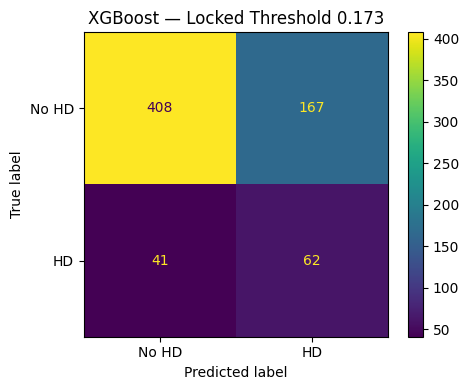

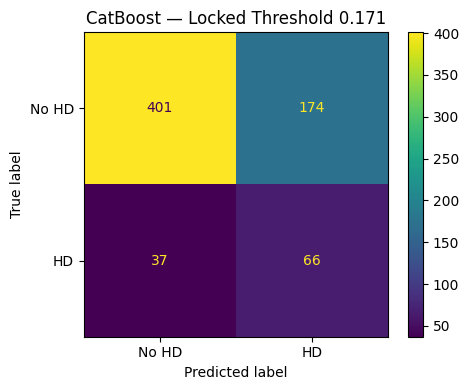

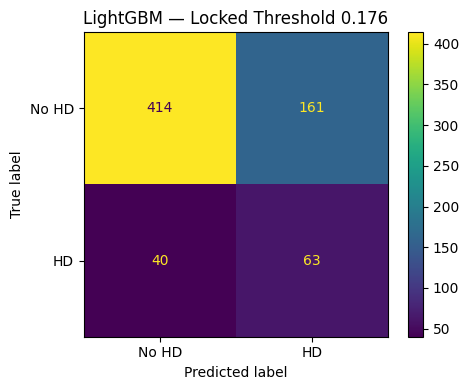

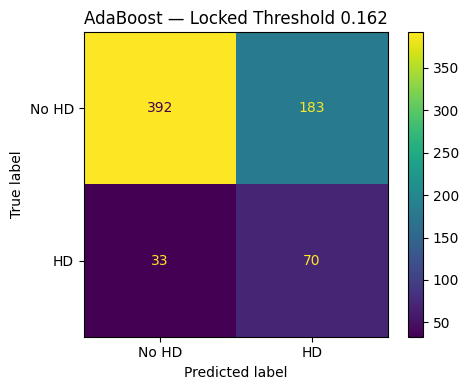

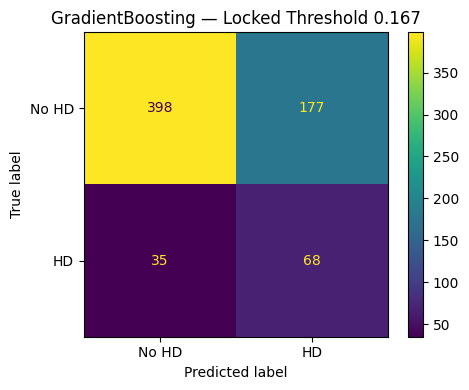

In [11]:
for name, stored in prediction_store.items():
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        stored["pred_locked"],
        display_labels=["No HD","HD"],
        values_format="d",
        ax=ax
    )
    ax.set_title(f"{name} — Locked Threshold {locked_thresholds[name]:.3f}")
    plt.tight_layout()
    plt.savefig(f"HD_V2_CM_{name}.png", dpi=300, bbox_inches="tight")
    plt.show()


## 11. ROC curves

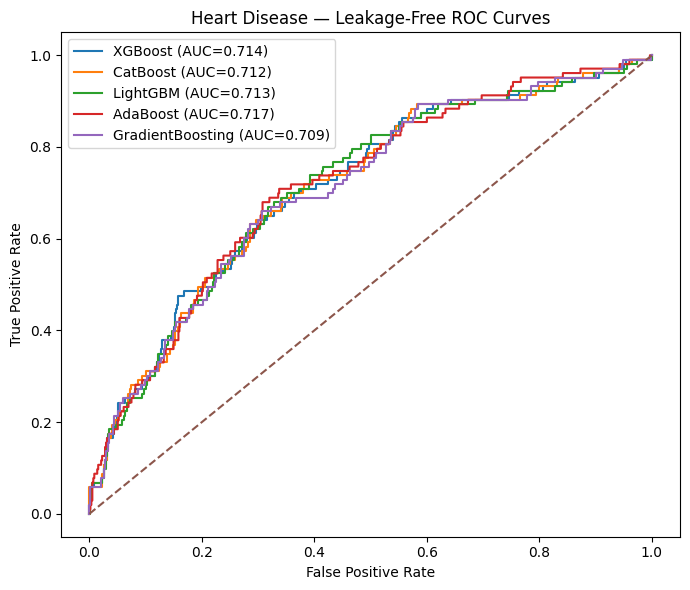

In [12]:
fig, ax = plt.subplots(figsize=(7,6))

for name, stored in prediction_store.items():
    fpr, tpr, _ = roc_curve(y_test, stored["prob"])
    auc = roc_auc_score(y_test, stored["prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0,1],[0,1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Heart Disease — Leakage-Free ROC Curves")
ax.legend()
plt.tight_layout()
plt.savefig("HD_V2_ROC.png", dpi=300, bbox_inches="tight")
plt.show()


## 12. Precision–Recall curves

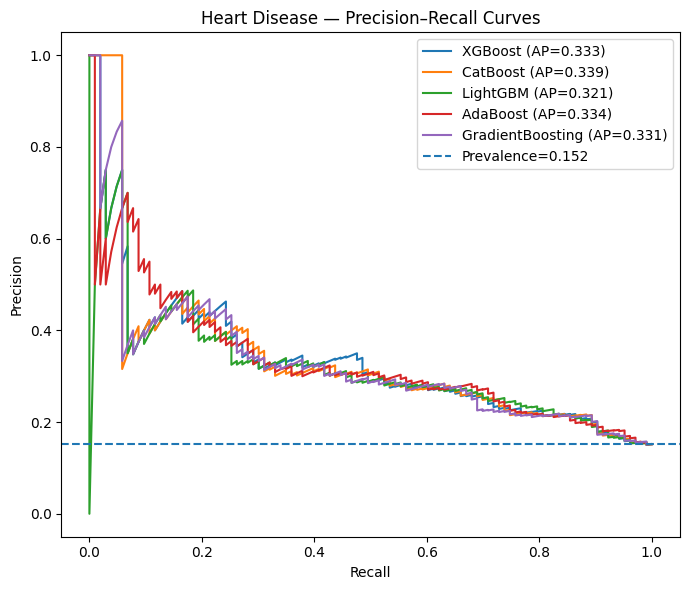

In [13]:
fig, ax = plt.subplots(figsize=(7,6))

for name, stored in prediction_store.items():
    precision, recall, _ = precision_recall_curve(y_test, stored["prob"])
    ap = average_precision_score(y_test, stored["prob"])
    ax.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

baseline = y_test.mean()
ax.axhline(baseline, linestyle="--", label=f"Prevalence={baseline:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Heart Disease — Precision–Recall Curves")
ax.legend()
plt.tight_layout()
plt.savefig("HD_V2_PR.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Calibration curves and Brier scores

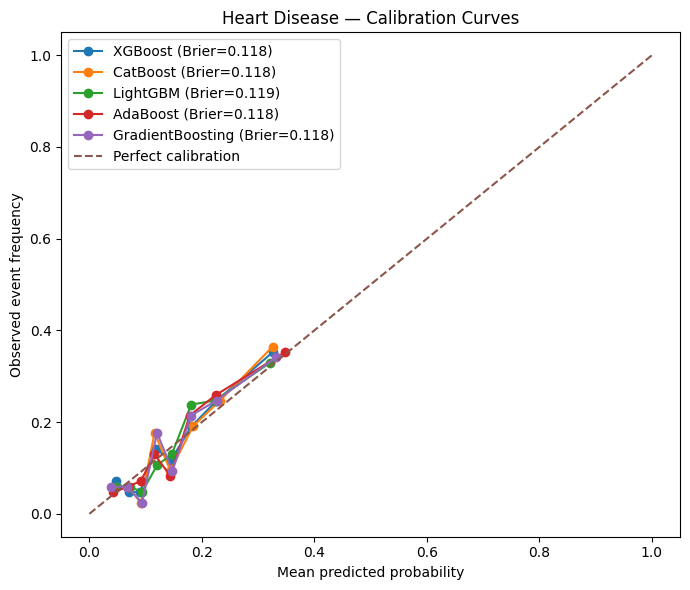

In [14]:
fig, ax = plt.subplots(figsize=(7,6))

for name, stored in prediction_store.items():
    frac_pos, mean_pred = calibration_curve(
        y_test, stored["prob"], n_bins=8, strategy="quantile"
    )
    brier = brier_score_loss(y_test, stored["prob"])
    ax.plot(mean_pred, frac_pos, marker="o", label=f"{name} (Brier={brier:.3f})")

ax.plot([0,1],[0,1], linestyle="--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed event frequency")
ax.set_title("Heart Disease — Calibration Curves")
ax.legend()
plt.tight_layout()
plt.savefig("HD_V2_Calibration.png", dpi=300, bbox_inches="tight")
plt.show()


## 14. Repeated stratified CV for statistical testing

For the revised statistical analysis, **matched CV splits** are the repeated observations.  
Metrics are not treated as independent repeated observations.

Here we use 5 folds × 5 repeats = 25 matched observations per model. The same splits are used for every algorithm.


In [15]:
outer_cv = RepeatedStratifiedKFold(
    n_splits=5, n_repeats=5, random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cv_rows = []

# Statistical comparison uses each model's tuned leakage-free BASE pipeline.
for name, estimator in best_estimators.items():
    print("Repeated CV:", name)
    scores = cross_validate(
        clone(estimator),
        X, y,
        cv=outer_cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    for i in range(len(scores["test_f1"])):
        cv_rows.append({
            "Model": name,
            "Split": i + 1,
            "Accuracy": scores["test_accuracy"][i],
            "Balanced_Accuracy": scores["test_balanced_accuracy"][i],
            "Precision": scores["test_precision"][i],
            "Sensitivity": scores["test_recall"][i],
            "F1": scores["test_f1"][i],
            "ROC_AUC": scores["test_roc_auc"][i],
            "PR_AUC": scores["test_average_precision"][i],
        })

cv_df = pd.DataFrame(cv_rows)
cv_summary = cv_df.groupby("Model")[
    ["Accuracy","Balanced_Accuracy","Precision","Sensitivity","F1","ROC_AUC","PR_AUC"]
].agg(["mean","std"])

display(cv_summary)
cv_df.to_csv("HD_V2_repeated_CV_scores.csv", index=False)
cv_summary.to_csv("HD_V2_repeated_CV_summary.csv")


Repeated CV: XGBoost
Repeated CV: CatBoost
Repeated CV: LightGBM
Repeated CV: AdaBoost
Repeated CV: GradientBoosting


Accuracy           Balanced_Accuracy           Precision  \
                      mean       std              mean       std      mean   
Model                                                                        
AdaBoost          0.661888  0.021294          0.650466  0.031793  0.255351   
CatBoost          0.682478  0.020800          0.645337  0.030790  0.261567   
GradientBoosting  0.673392  0.020548          0.644722  0.030556  0.257213   
LightGBM          0.673982  0.018206          0.635865  0.029953  0.252686   
XGBoost           0.677522  0.020423          0.640504  0.032351  0.256699   

                           Sensitivity                  F1            \
                       std        mean       std      mean       std   
Model                                                                  
AdaBoost          0.022528    0.634040  0.059180  0.363856  0.031386   
CatBoost          0.024208    0.591901  0.054300  0.362610  0.032314   
GradientBoosting  0.022785    0.603480  0.055878  0.360483  0.031135   
LightGBM          0.021714    0.581031  0.056924  0.352013  0.030629   
XGBoost           0.024163    0.587248  0.060208  0.357024  0.033409   

                   ROC_AUC              PR_AUC            
                      mean       std      mean       std  
Model                                                     
AdaBoost          0.707650  0.032853  0.334070  0.040208  
CatBoost          0.699898  0.031416  0.329817  0.038570  
GradientBoosting  0.701259  0.032371  0.326823  0.040399  
LightGBM          0.694684  0.031026  0.316947  0.040513  
XGBoost           0.699047  0.031075  0.327356  0.040207

## 15. Select the XAI model without using the held-out test set

To avoid choosing a model because it happened to perform best on the test set, the XAI model is selected using **training-only out-of-fold ROC–AUC** from Section 6.


In [16]:
xai_model_name = threshold_df.sort_values(
    ["OOF_ROC_AUC", "OOF_F1_at_Locked_Threshold"],
    ascending=False
).iloc[0]["Model"]

print("XAI model selected from training-only evidence:", xai_model_name)

# Use the corresponding tuned BASE pipeline for tree-based explanations.
xai_pipeline = best_estimators[xai_model_name]

# It is already fitted by GridSearchCV refit; refit explicitly on full training data for clarity.
xai_pipeline.fit(X_train, y_train)


XAI model selected from training-only evidence: AdaBoost


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', MinMaxScaler()),
                ('oversampler', RandomOverSampler(random_state=42)),
                ('model',
                 AdaBoostClassifier(learning_rate=0.1, n_estimators=100,
                                    random_state=42))])

## 16. Prepare transformed data for SHAP/LIME

SHAP and LIME explain the underlying fitted boosting classifier.  
Calibration changes probability mapping but not the underlying learned feature relationships, so explanations are generated for the tuned base classifier.

No test observations are used to build the explainer background/reference distribution.


In [17]:
# Extract fitted preprocessing components
imputer = xai_pipeline.named_steps["imputer"]
scaler = xai_pipeline.named_steps["scaler"]
base_model = xai_pipeline.named_steps["model"]

X_train_imp = imputer.transform(X_train)
X_test_imp = imputer.transform(X_test)

X_train_trans = scaler.transform(X_train_imp)
X_test_trans = scaler.transform(X_test_imp)

feature_names = list(X.columns)

X_train_trans_df = pd.DataFrame(X_train_trans, columns=feature_names, index=X_train.index)
X_test_trans_df = pd.DataFrame(X_test_trans, columns=feature_names, index=X_test.index)

print(xai_model_name, "prepared for XAI")


AdaBoost prepared for XAI


## 17. SHAP global explanation

XAI model: AdaBoost
Underlying model type: <class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'>
AdaBoost detected: using model-agnostic SHAP explainer...


PermutationExplainer explainer: 679it [00:24, 20.44it/s]                         


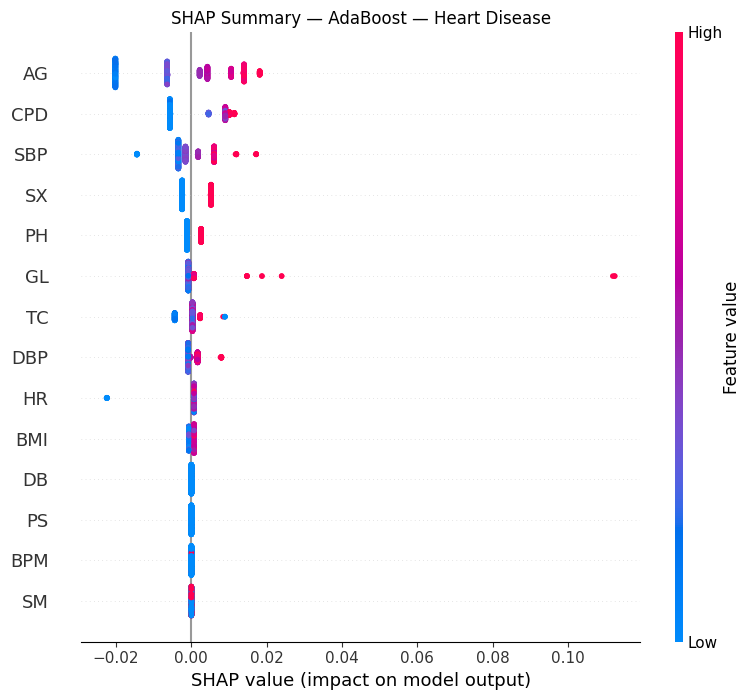

In [18]:
import shap
import numpy as np

print("XAI model:", xai_model_name)
print("Underlying model type:", type(base_model))

# Use TreeExplainer where directly supported.
tree_supported = xai_model_name in [
    "XGBoost",
    "CatBoost",
    "LightGBM",
    "GradientBoosting"
]

if tree_supported:
    print("Using SHAP TreeExplainer...")
    
    explainer = shap.TreeExplainer(base_model)
    shap_values = explainer.shap_values(X_test_trans_df)

    # Handle binary-classification outputs across SHAP versions
    if isinstance(shap_values, list):
        shap_for_plot = shap_values[-1]
    else:
        shap_for_plot = shap_values

else:
    # AdaBoost fallback
    print("AdaBoost detected: using model-agnostic SHAP explainer...")

    # Use a representative training-only background sample
    background = shap.sample(
        X_train_trans_df,
        min(100, len(X_train_trans_df)),
        random_state=RANDOM_STATE
    )

    # Explain probability of the positive class
    def predict_positive_probability(X_input):
        if isinstance(X_input, pd.DataFrame):
            X_array = X_input.values
        else:
            X_array = np.asarray(X_input)
        return base_model.predict_proba(X_array)[:, 1]

    explainer = shap.Explainer(
        predict_positive_probability,
        background,
        algorithm="permutation"
    )

    # To keep computation manageable, explain the complete test set
    # or reduce max_evals/sample size if computation is slow.
    shap_exp = explainer(
        X_test_trans_df,
        max_evals=2 * X_test_trans_df.shape[1] + 1
    )

    shap_for_plot = shap_exp.values

# Global SHAP summary plot
shap.summary_plot(
    shap_for_plot,
    X_test_trans_df,
    feature_names=feature_names,
    show=False
)

plt.title(f"SHAP Summary — {xai_model_name} — Heart Disease")
plt.tight_layout()
plt.savefig(
    "HD_V2_SHAP_summary.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 18. SHAP global mean absolute importance

,Feature,Mean_Absolute_SHAP
1,AG,0.011936
3,CPD,0.007040
9,SBP,0.003894
0,SX,0.003592
6,PH,0.001615
13,GL,0.001532
8,TC,0.001299
10,DBP,0.001224
12,HR,0.001080
11,BMI,0.000694


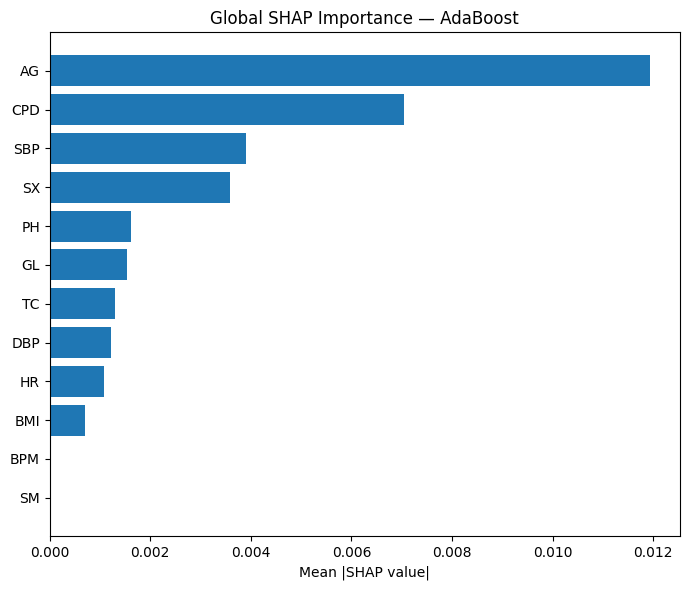

In [19]:
# Mean absolute SHAP importance
shap_array = np.asarray(shap_for_plot)

# Handle possible 3-D output from some explainers
if shap_array.ndim == 3:
    shap_array = shap_array[:, :, -1]

mean_abs_shap = np.abs(shap_array).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

display(shap_importance_df)

shap_importance_df.to_csv(
    "HD_V2_SHAP_global_importance.csv",
    index=False
)

top = (
    shap_importance_df
    .head(12)
    .sort_values("Mean_Absolute_SHAP")
)

plt.figure(figsize=(7, 6))
plt.barh(
    top["Feature"],
    top["Mean_Absolute_SHAP"]
)
plt.xlabel("Mean |SHAP value|")
plt.title(f"Global SHAP Importance — {xai_model_name}")
plt.tight_layout()
plt.savefig(
    "HD_V2_SHAP_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 19. Representative SHAP cases from the untouched test set

To avoid cherry-picking extreme 0/1 probabilities, representative cases are selected among correctly classified observations whose calibrated probabilities are closest to the **median probability within their respective true class**.


In [20]:
final_prob = prediction_store[xai_model_name]["prob"]
final_pred = prediction_store[xai_model_name]["pred_locked"]
yt = y_test.to_numpy()

def representative_index(target_class):
    candidates = np.where((yt == target_class) & (final_pred == target_class))[0]
    if len(candidates) == 0:
        candidates = np.where(yt == target_class)[0]
    probs = final_prob[candidates]
    med = np.median(probs)
    return int(candidates[np.argmin(np.abs(probs - med))])

rep_neg = representative_index(0)
rep_pos = representative_index(1)

print("Representative negative test row:", rep_neg, "probability:", final_prob[rep_neg])
print("Representative positive test row:", rep_pos, "probability:", final_prob[rep_pos])


Representative negative test row: 2 probability: 0.08934928956914277
Representative positive test row: 89 probability: 0.23566508481929854


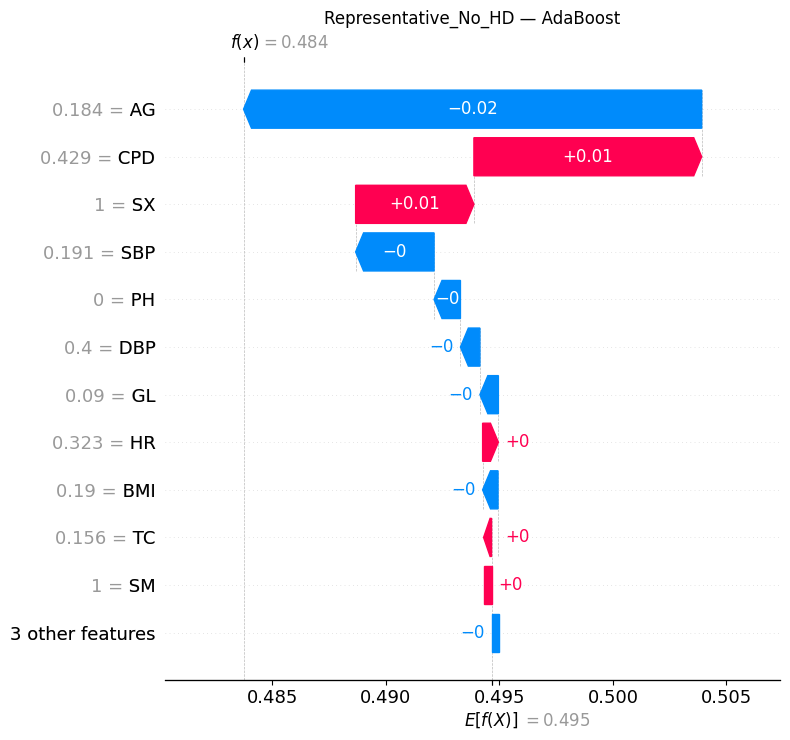

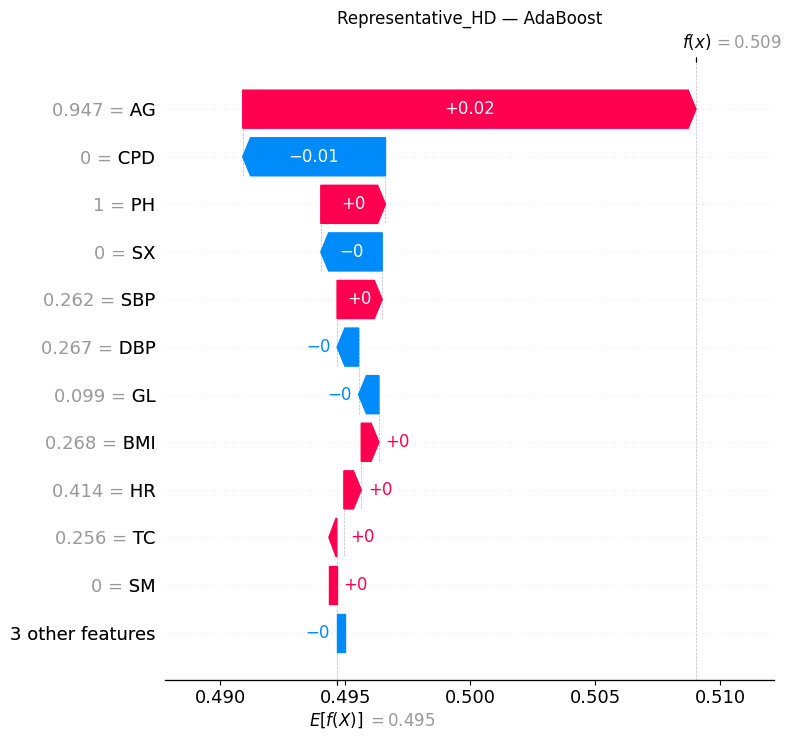

In [21]:
# SHAP explanations for representative cases

shap_array = np.asarray(shap_for_plot)

if shap_array.ndim == 3:
    shap_array = shap_array[:, :, -1]

for label, pos in [
    ("Representative_No_HD", rep_neg),
    ("Representative_HD", rep_pos)
]:

    # For model-agnostic AdaBoost explanation
    if not tree_supported:
        case_exp = shap_exp[pos]

        shap.plots.waterfall(
            case_exp,
            max_display=12,
            show=False
        )

    # For TreeExplainer-supported models
    else:
        expected = explainer.expected_value

        if isinstance(expected, (list, np.ndarray)):
            expected_array = np.asarray(expected).ravel()
            expected_value = expected_array[-1]
        else:
            expected_value = expected

        case_exp = shap.Explanation(
            values=shap_array[pos],
            base_values=expected_value,
            data=X_test_trans_df.iloc[pos].values,
            feature_names=feature_names
        )

        shap.plots.waterfall(
            case_exp,
            max_display=12,
            show=False
        )

    plt.title(f"{label} — {xai_model_name}")
    plt.tight_layout()
    plt.savefig(
        f"HD_V2_SHAP_{label}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

## 20. LIME representative local explanations

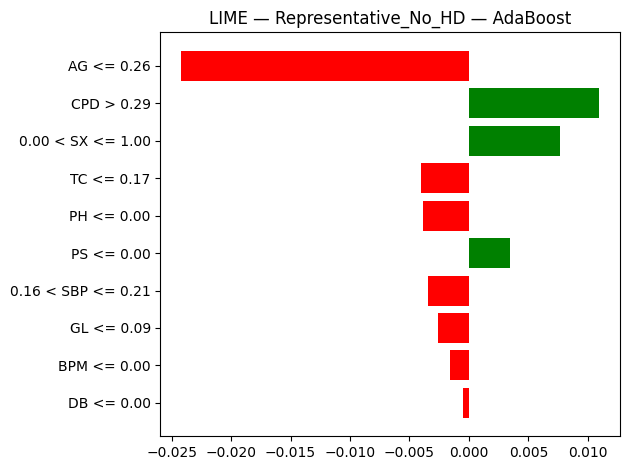

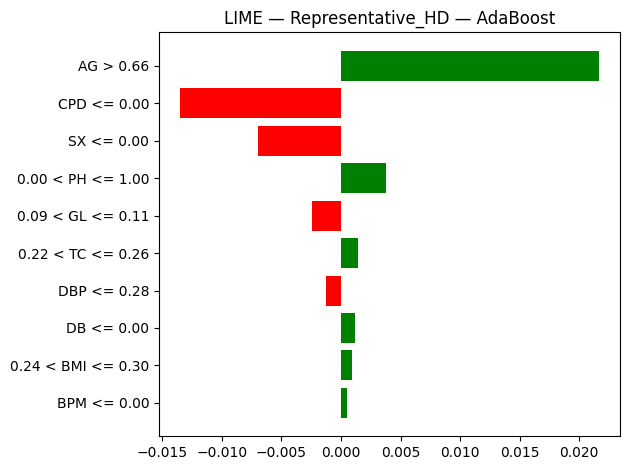

,Case,Rule,Weight
0,Representative_No_HD,AG <= 0.26,-0.024175
1,Representative_No_HD,CPD > 0.29,0.010942
2,Representative_No_HD,0.00 < SX <= 1.00,0.007693
3,Representative_No_HD,TC <= 0.17,-0.004067
4,Representative_No_HD,PH <= 0.00,-0.003857
5,Representative_No_HD,PS <= 0.00,0.003453
6,Representative_No_HD,0.16 < SBP <= 0.21,-0.003418
7,Representative_No_HD,GL <= 0.09,-0.002641
8,Representative_No_HD,BPM <= 0.00,-0.001565
9,Representative_No_HD,DB <= 0.00,-0.000489


In [22]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_trans_df.to_numpy(),
    feature_names=feature_names,
    class_names=["No Heart Disease", "Heart Disease"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

# LIME explains the underlying tuned classifier in transformed feature space.
def lime_predict_fn(arr):
    return base_model.predict_proba(arr)

lime_rows = []

for label, pos in [("Representative_No_HD", rep_neg), ("Representative_HD", rep_pos)]:
    exp = lime_explainer.explain_instance(
        X_test_trans_df.iloc[pos].to_numpy(),
        lime_predict_fn,
        num_features=min(10, len(feature_names))
    )

    fig = exp.as_pyplot_figure()
    plt.title(f"LIME — {label} — {xai_model_name}")
    plt.tight_layout()
    plt.savefig(f"HD_V2_LIME_{label}.png", dpi=300, bbox_inches="tight")
    plt.show()

    for rule, weight in exp.as_list():
        lime_rows.append({
            "Case": label,
            "Rule": rule,
            "Weight": weight
        })

lime_df = pd.DataFrame(lime_rows)
display(lime_df)
lime_df.to_csv("HD_V2_LIME_representative_cases.csv", index=False)


## 21. Manuscript-ready summary table

For clinical interpretation, **ROC–AUC/PR–AUC, sensitivity, specificity, F1 and calibration should be considered alongside accuracy**.


In [23]:
manuscript_table = (
    test_results_df[test_results_df["Threshold_Type"] == "Training_Optimized"]
    [["Model","Threshold","Accuracy","Balanced_Accuracy","Precision",
      "Sensitivity","Specificity","F1","ROC_AUC","PR_AUC","Brier"]]
    .copy()
)

for c in ["Accuracy","Balanced_Accuracy","Precision","Sensitivity","Specificity","F1","ROC_AUC","PR_AUC"]:
    manuscript_table[c] = (100 * manuscript_table[c]).round(2)

manuscript_table["Brier"] = manuscript_table["Brier"].round(4)
manuscript_table["Threshold"] = manuscript_table["Threshold"].round(4)

display(manuscript_table)
manuscript_table.to_csv("HD_V2_manuscript_summary_table.csv", index=False)


,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC,Brier
1,XGBoost,0.1730,69.32,65.58,27.07,60.19,70.96,37.35,71.36,33.29,0.1183
3,CatBoost,0.1712,68.88,66.91,27.50,64.08,69.74,38.48,71.20,33.88,0.1185
5,LightGBM,0.1759,70.35,66.58,28.12,61.17,72.00,38.53,71.34,32.07,0.1185
7,AdaBoost,0.1617,68.14,68.07,27.67,67.96,68.17,39.33,71.71,33.43,0.1177
9,GradientBoosting,0.1671,68.73,67.62,27.76,66.02,69.22,39.08,70.92,33.08,0.1183


## 22. Files to retain for the revision

### Numerical outputs
- `HD_V2_hyperparameters.csv`
- `HD_V2_training_only_thresholds.csv`
- `HD_V2_test_results_default_and_optimized.csv`
- `HD_V2_results_with_95CI.csv`
- `HD_V2_repeated_CV_scores.csv`
- `HD_V2_repeated_CV_summary.csv`
- `HD_V2_manuscript_summary_table.csv`
- `HD_V2_SHAP_global_importance.csv`
- `HD_V2_LIME_representative_cases.csv`

### Figures
- model-specific confusion matrices
- `HD_V2_ROC.png`
- `HD_V2_PR.png`
- `HD_V2_Calibration.png`
- `HD_V2_SHAP_summary.png`
- `HD_V2_SHAP_importance.png`
- representative SHAP waterfall plots
- representative LIME plots

### Interpretation rule
Do **not** describe SHAP/LIME features as causal factors. They indicate features that influenced the fitted model's predictions.  
Do **not** interpret calibrated probabilities of 0 or 1 as clinical certainty.
